In [14]:
# 

# ==============================================================================
# STEP 1: SETUP & OPTIMIZATION
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ปรับการแสดงผลเพื่อให้ Tracking ข้อมูลได้ง่าย
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")



In [15]:
# ==============================================================================
# STEP 2: DATA LOADING (Handling Categorical Labels)
# ==============================================================================
# Why: ใช้ convert_categoricals=False เพื่อป้องกัน Error จากชื่อซ้ำใน Metadata ของ Stata
file_2017 = 'shocksclean.dta'
df_17 = pd.read_stata(file_2017, convert_categoricals=False)

print(f"Loaded Wave 6 (2017) successfully: {len(df_17)} rows")



Loaded Wave 6 (2017) successfully: 3323 rows


In [16]:
# ==============================================================================
# STEP 3: ADVANCED DATA CLEANING
# ==============================================================================
# จัดการค่าว่างและ 'none' เพื่อป้องกัน ValueError
def research_cleaning(df):
    # เปลี่ยนรหัส Missing Stata
    df = df.replace([-9, -99, -9.0, -99.0], np.nan)
    
    # จัดการคอลัมน์การเงิน (Total Loss: _x31005a)
    target_cols = ['_x31005a', '_x31005b', '_x31006a']
    for col in target_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace('none', '0', case=False).str.strip()
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    return df

df_17 = research_cleaning(df_17)



In [17]:
# ==============================================================================
# STEP 4: COPING STRATEGY RECONSTRUCTION (เจาะลึก _x31008)
# ==============================================================================
# Why: แปลงจากคำตอบแบบลำดับ (1st, 2nd, 3rd) ให้เป็น Binary (Yes/No) เหมือนปี 2022
coping_mapping = {
    11: 'sold_assets', 12: 'sold_assets', 13: 'sold_assets', 14: 'sold_assets',
    15: 'used_savings', 16: 'used_insurance',
    17: 'borrowed_informal', 18: 'borrowed_informal', 19: 'borrowed_informal', 20: 'borrowed_informal',
    21: 'borrowed_formal', 22: 'borrowed_formal', 23: 'borrowed_formal', 24: 'borrowed_formal', 25: 'borrowed_formal',
    28: 'gov_help', 29: 'gov_help', 30: 'relatives_help', 31: 'relatives_help'
}

# สร้างคอลัมน์ Yes/No (0 หรือ 1)
coping_categories = ['sold_assets', 'used_savings', 'used_insurance', 'borrowed_informal', 'borrowed_formal', 'gov_help']
for cat in coping_categories:
    df_17[f'coping_{cat}'] = 0

# ตรวจสอบการใช้งานจากทุกลำดับ (Coping 1, 2, 3)
for col in ['_x31008', '_x31009', '_x31010']:
    if col in df_17.columns:
        for code, cat_name in coping_mapping.items():
            df_17.loc[df_17[col] == code, f'coping_{cat_name}'] = 1



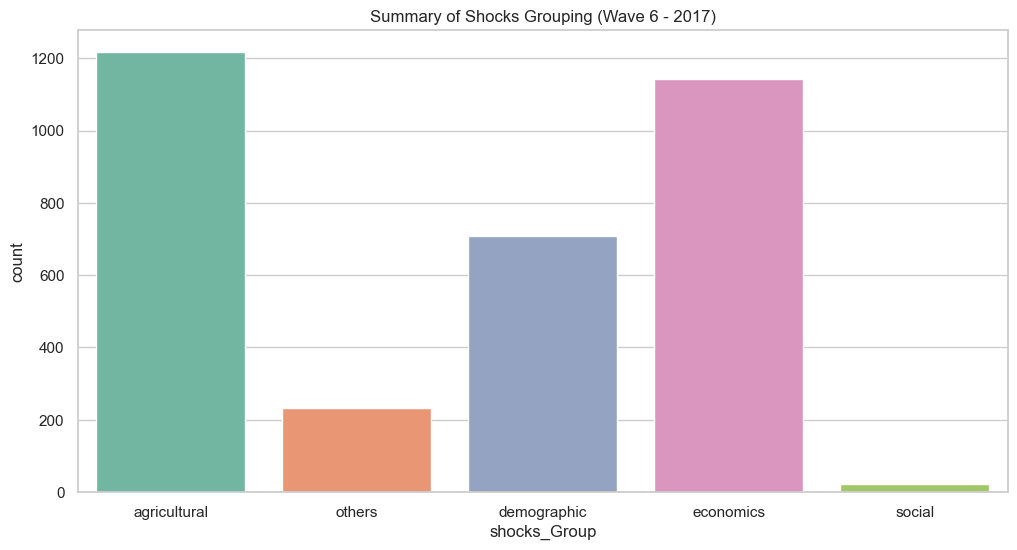

✅ Process Completed. File saved as shocks_2017_cleaned_final.csv


In [18]:
# ==============================================================================
# STEP 5: SHOCK CATEGORIZATION (Harmonization)
# ==============================================================================
# Mapping รหัส Shock (_x31002) เข้ากลุ่มมาตรฐาน
shock_mapping = {
    10: 'agricultural', 11: 'agricultural', 63: 'agricultural', 55: 'agricultural',
    1: 'demographic', 2: 'demographic', 3: 'demographic', 24: 'demographic',
    5: 'economics', 6: 'economics', 18: 'economics', 21: 'economics', 22: 'economics', 62: 'economics',
    8: 'social', 70: 'social', 77: 'economics'
}

# สร้างตัวแปรวิเคราะห์
df_17['shocks_Group'] = df_17['_x31002'].map(shock_mapping).fillna('others')
df_17['survey_year'] = 2017

# ==============================================================================
# STEP 6: EXPORT & FINAL SUMMARY
# ==============================================================================
output_file = 'shocks_2017_cleaned_final.csv'
df_17.to_csv(output_file, index=False)

# แสดงกราฟสรุปเพื่อ Recheck ข้อมูล
sns.countplot(data=df_17, x='shocks_Group', palette='Set2')
plt.title('Summary of Shocks Grouping (Wave 6 - 2017)')
plt.show()

print(f"✅ Process Completed. File saved as {output_file}")